# Time Series Modelling in Quantitative Finance
## A Beginner's Guide

Welcome! This notebook walks you through the key tools that quants use to understand, model, and trade financial time series — **no prior knowledge required**.

### What is a time series?

A **time series** is a sequence of numbers recorded over time: daily stock prices, weekly volatility, monthly interest rates. The key challenge is that each value is *connected* to the ones before it — today's stock price depends on yesterday's; this week's volatility looks similar to last week's. The tools in this notebook are designed to measure, model, and exploit those connections.

### What you'll learn

| Section | Concept | One-line summary |
|---------|---------|-----------------|
| 1 | Setup | Import libraries |
| 2 | Mock Data | Generate four different types of financial time series |
| 3 | Stationarity | Test whether a series has a stable mean and variance over time |
| 4 | ACF & PACF | Detect how today's value depends on past values |
| 5 | ARIMA | Forecast a series using its own past values and past surprises |
| 6 | GARCH | Model volatility that changes over time (risk spikes and calm periods) |
| 7 | Decomposition | Separate trend, season, and random noise from a series |
| 8 | Mean Reversion | Measure whether and how fast a series snaps back to its average |
| 9 | Co-integration | Find pairs of assets that share a long-run equilibrium |
| 10 | Trading Strategy | Turn the statistical analysis into concrete buy/sell rules |

> **How to use this notebook:** Read each grey explanation box *before* the code. The box tells you *why* a tool exists; the code shows *how* to run it. Focus on the charts — the numbers matter less than the shapes.

## 1. Import Required Libraries

Load essential libraries for time series analysis, statistical testing, and visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, jarque_bera, norm
from statsmodels.tsa.stattools import adfuller, acf, pacf, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Generate Mock Time Series Data

Create synthetic time series data with different characteristics: trend, seasonality, stationarity, and mean reversion.

### Why Do We Generate Synthetic Data First?

> **In plain English:** We create *fake-but-realistic* financial data because we already know exactly how it was constructed. This lets us verify that our analysis tools produce the right answers on data with known properties — before we apply them to real market data where we don't know the ground truth.
>
> Think of it like a flight simulator: pilots master the cockpit on a simulator before flying a real plane. Quants use synthetic series to validate their models before risking real money.

**The Core Problem:** A single random walk cannot teach you to distinguish between fundamentally different market regimes. Real quant work requires identifying which regime you're in before choosing any model.

**The Four Series We'll Generate:**

| Series Type | What It Looks Like | Financial Analogy | Typical Market |
|------------|-------------------|------------------|----------------|
| **Trend + noise** | Drifts in one direction, won't stay near old average | Tech stock in a bull market | US equities 2010–2021 |
| **Mean-reverting (OU)** | Always snaps back toward a central value | Interest rate spread | Bond spreads, FX |
| **Seasonal** | Regular up-and-down cycles at predictable intervals | Agricultural commodity | Natural gas, wheat |
| **ARIMA(1,1,1)** | Autocorrelated drift, shaped by past surprises | Macro-driven exchange rate | EUR/USD, JPY/USD |

**Practical Examples:**
- **Trend-following vs. Mean-Reversion Strategies**: Trend-following CTAs (AHL, Winton) profit when a series persists in one direction. Mean-reversion funds (stat-arb desks) profit when the series reverts. Knowing which regime you're in determines which tool to apply.
- **Seasonal Adjustment in Fixed Income**: Bond yields have year-end seasonal patterns (balance sheet effects, tax flows). Generating synthetic seasonal series lets you test if your model correctly separates the seasonal component from genuine rate changes.
- **ARIMA-Type Processes in FX**: Exchange rates exhibit autocorrelation during macro-driven trending episodes. Mock ARIMA data tests whether your order-selection algorithm identifies these dependencies correctly.

Mock Time Series Data Generated:
            trend_series  mean_revert    seasonal       arima
2022-01-01    100.993428   100.000000  100.572583  100.000000
2022-01-02     99.823672   100.926178  101.648662  101.912238
2022-01-03    101.495778   102.789285  101.423093  100.511988
2022-01-04    103.346661   101.251253  100.806931   98.340084
2022-01-05     99.932495   101.751660  100.348742   98.506382
2022-01-06    100.032728   101.013434  101.941660   98.761435
2022-01-07    103.759628   100.475637  101.883908   98.248294
2022-01-08    102.236272    99.859462  102.631675  100.069815
2022-01-09     99.862654    99.002498  102.616633  102.370332
2022-01-10    101.986924    99.100894  103.274762  102.172196

Shape: (500, 4)


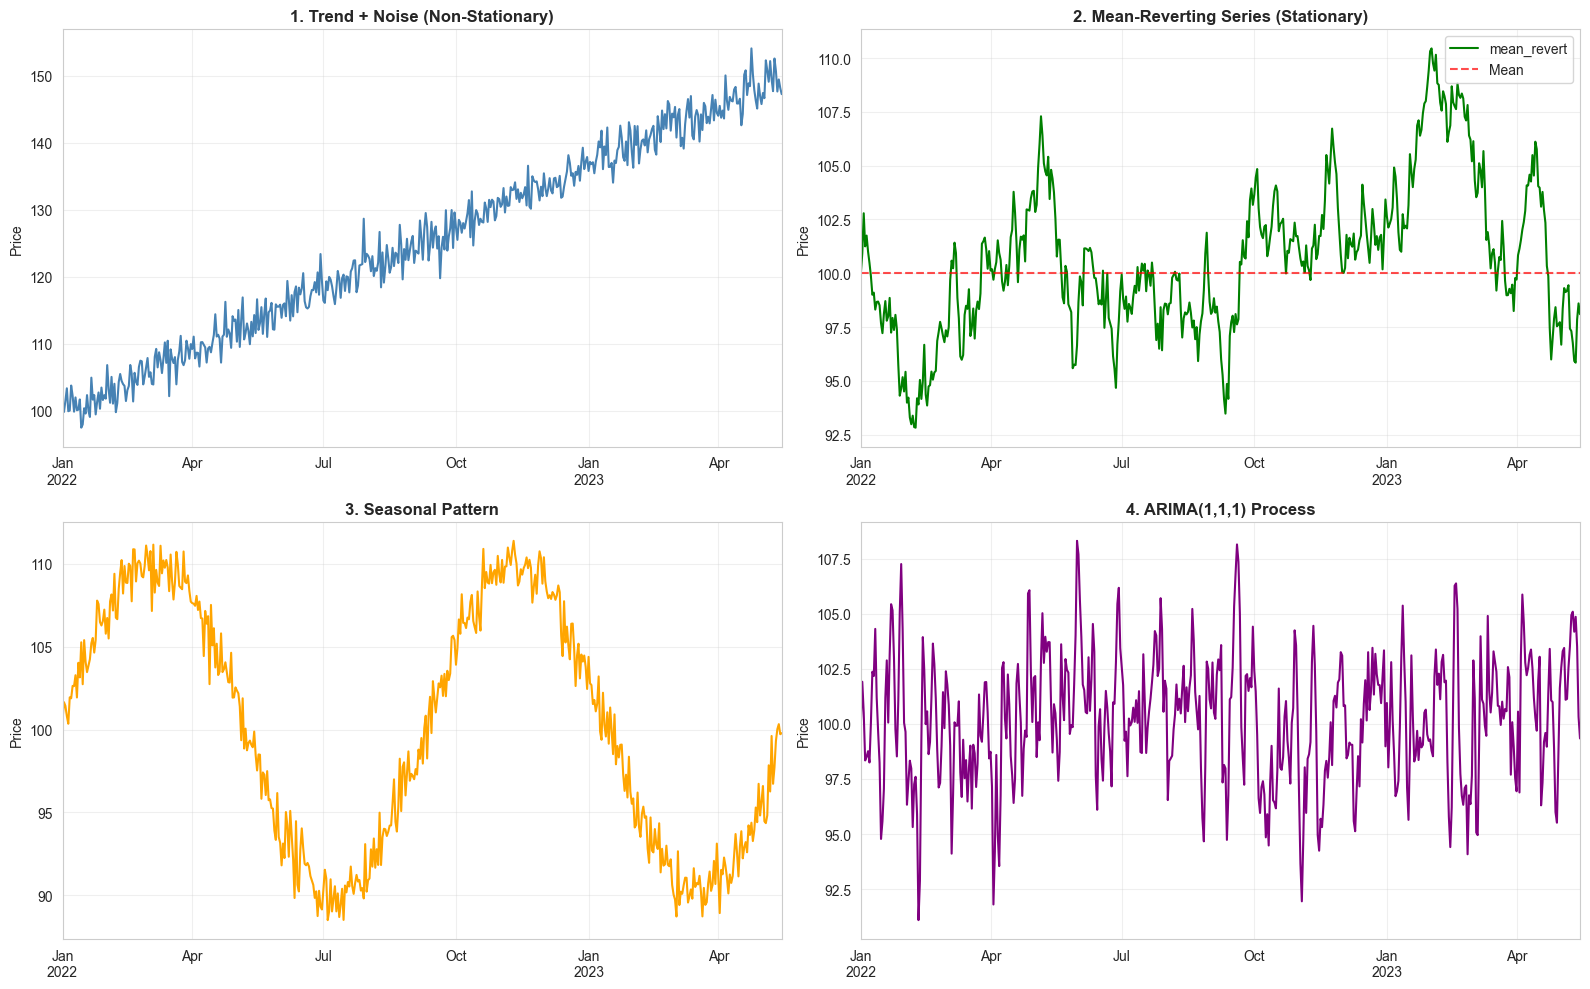

In [3]:
# Generate time periods
n_periods = 500
dates = pd.date_range(start='2022-01-01', periods=n_periods, freq='D')

# 1. Trend + Noise (Non-stationary)
trend = np.linspace(100, 150, n_periods)
noise_trend = trend + np.random.normal(0, 2, n_periods)

# 2. Mean-reverting series (Stationary)
mean_reversion = 100
reversion_speed = 0.05
mean_revert_series = np.zeros(n_periods)
mean_revert_series[0] = 100
for t in range(1, n_periods):
    mean_revert_series[t] = mean_revert_series[t-1] + reversion_speed * (mean_reversion - mean_revert_series[t-1]) + np.random.normal(0, 1)

# 3. Seasonal pattern
seasonal = 100 + 10 * np.sin(2 * np.pi * np.arange(n_periods) / 252) + np.random.normal(0, 1, n_periods)

# 4. ARIMA(1,1,1) process
ar_coef = 0.6
ma_coef = 0.3
arima_series = np.zeros(n_periods)
residuals = np.random.normal(0, 2, n_periods)
for t in range(1, n_periods):
    arima_series[t] = ar_coef * arima_series[t-1] + residuals[t] + ma_coef * residuals[t-1]

# Create DataFrame
df_ts = pd.DataFrame({
    'trend_series': noise_trend,
    'mean_revert': mean_revert_series,
    'seasonal': seasonal,
    'arima': arima_series + 100
}, index=dates)

print("Mock Time Series Data Generated:")
print(df_ts.head(10))
print(f"\nShape: {df_ts.shape}")

# Plot all series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df_ts['trend_series'].plot(ax=axes[0, 0], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('1. Trend + Noise (Non-Stationary)', fontweight='bold')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(alpha=0.3)

df_ts['mean_revert'].plot(ax=axes[0, 1], color='green', linewidth=1.5)
axes[0, 1].axhline(mean_reversion, color='red', linestyle='--', alpha=0.7, label='Mean')
axes[0, 1].set_title('2. Mean-Reverting Series (Stationary)', fontweight='bold')
axes[0, 1].set_ylabel('Price')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

df_ts['seasonal'].plot(ax=axes[1, 0], color='orange', linewidth=1.5)
axes[1, 0].set_title('3. Seasonal Pattern', fontweight='bold')
axes[1, 0].set_ylabel('Price')
axes[1, 0].grid(alpha=0.3)

df_ts['arima'].plot(ax=axes[1, 1], color='purple', linewidth=1.5)
axes[1, 1].set_title('4. ARIMA(1,1,1) Process', fontweight='bold')
axes[1, 1].set_ylabel('Price')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Stationarity Testing (ADF & KPSS)

Test whether time series are stationary using Augmented Dickey-Fuller (ADF) and KPSS tests. Stationarity is crucial for time series modeling.

### Why Do We Test for Stationarity?

> **In plain English:** A *stationary* series has a stable average and stable variance — it wobbles around a fixed level. A *non-stationary* series drifts freely, going wherever randomness takes it, never settling.
>
> **Why it matters:** Most time series models assume the patterns they learn from past data will also appear in future data. Non-stationary data violates this — its average keeps changing, so any pattern learned may be completely useless for forecasting.
>
> **Simple example:**
> - A stock's **price** is non-stationary — it can drift to any level over years.
> - A stock's **daily return** is usually stationary — returns cluster near zero over long horizons.
> - **Rule of thumb:** Always model *returns*, not *prices*.

**The Core Problem:** Most time series models (ARIMA, VAR, OLS regression) assume statistical properties — mean, variance, autocorrelation — are constant over time. Non-stationary data violates this assumption, making model estimates meaningless and forecasts unreliable.

**Practical Examples:**
- **Spurious Regression (The Classic Trap)**: Regress the S&P 500 *level* against US GDP *level*. You'll get R² > 0.95 and a highly significant t-statistic — but the relationship is entirely spurious because both are non-stationary random walks trending upward. The ADF test catches this before you build an invalid model.
- **Pair Trading Pre-Check**: Before entering a pairs trade on two bank stocks, a quant runs ADF on the spread. If the spread is non-stationary (unit root), the strategy will have unlimited drawdown because the spread can drift forever. Only stationary spreads mean-revert reliably.
- **Federal Reserve Research**: When analyzing the relationship between monetary base and inflation, Fed economists first test both series for integration order, then apply error-correction models only to co-integrated pairs. Using ARIMA on a non-stationary series produces wrong standard errors and invalid policy conclusions.

**ADF vs. KPSS — Why Use Both?**

| Test | Null Hypothesis | p < 0.05 means… |
|------|----------------|-----------------|
| **ADF** | Unit root (non-stationary) | Series **is** stationary ✅ |
| **KPSS** | Stationary | Series **is not** stationary ❌ |

> Using both tests avoids false conclusions. If they agree → confident result. If they disagree → borderline case, investigate further (structural breaks, near-unit-root).

STATIONARITY TEST RESULTS
      Series   ADF Stat  ADF p-value  KPSS Stat  KPSS p-value Stationary (ADF) Stationary (KPSS)
trend_series  -0.441455 9.029438e-01   3.935600          0.01               No                No
 mean_revert  -3.167304 2.195700e-02   1.267397          0.01              Yes                No
    seasonal  -3.072283 2.867353e-02   0.750281          0.01              Yes                No
       arima -11.137904 3.161355e-20   0.137583          0.10              Yes               Yes

AFTER FIRST DIFFERENCING
                    Series   ADF Stat  ADF p-value  KPSS Stat  KPSS p-value Stationary (ADF) Stationary (KPSS)
trend_series (Differenced) -10.640861 4.934249e-19   0.051409           0.1              Yes               Yes
 mean_revert (Differenced) -23.191943 0.000000e+00   0.037714           0.1              Yes               Yes
    seasonal (Differenced)  -1.717136 4.223059e-01   0.124386           0.1               No               Yes
       arima (Diffe

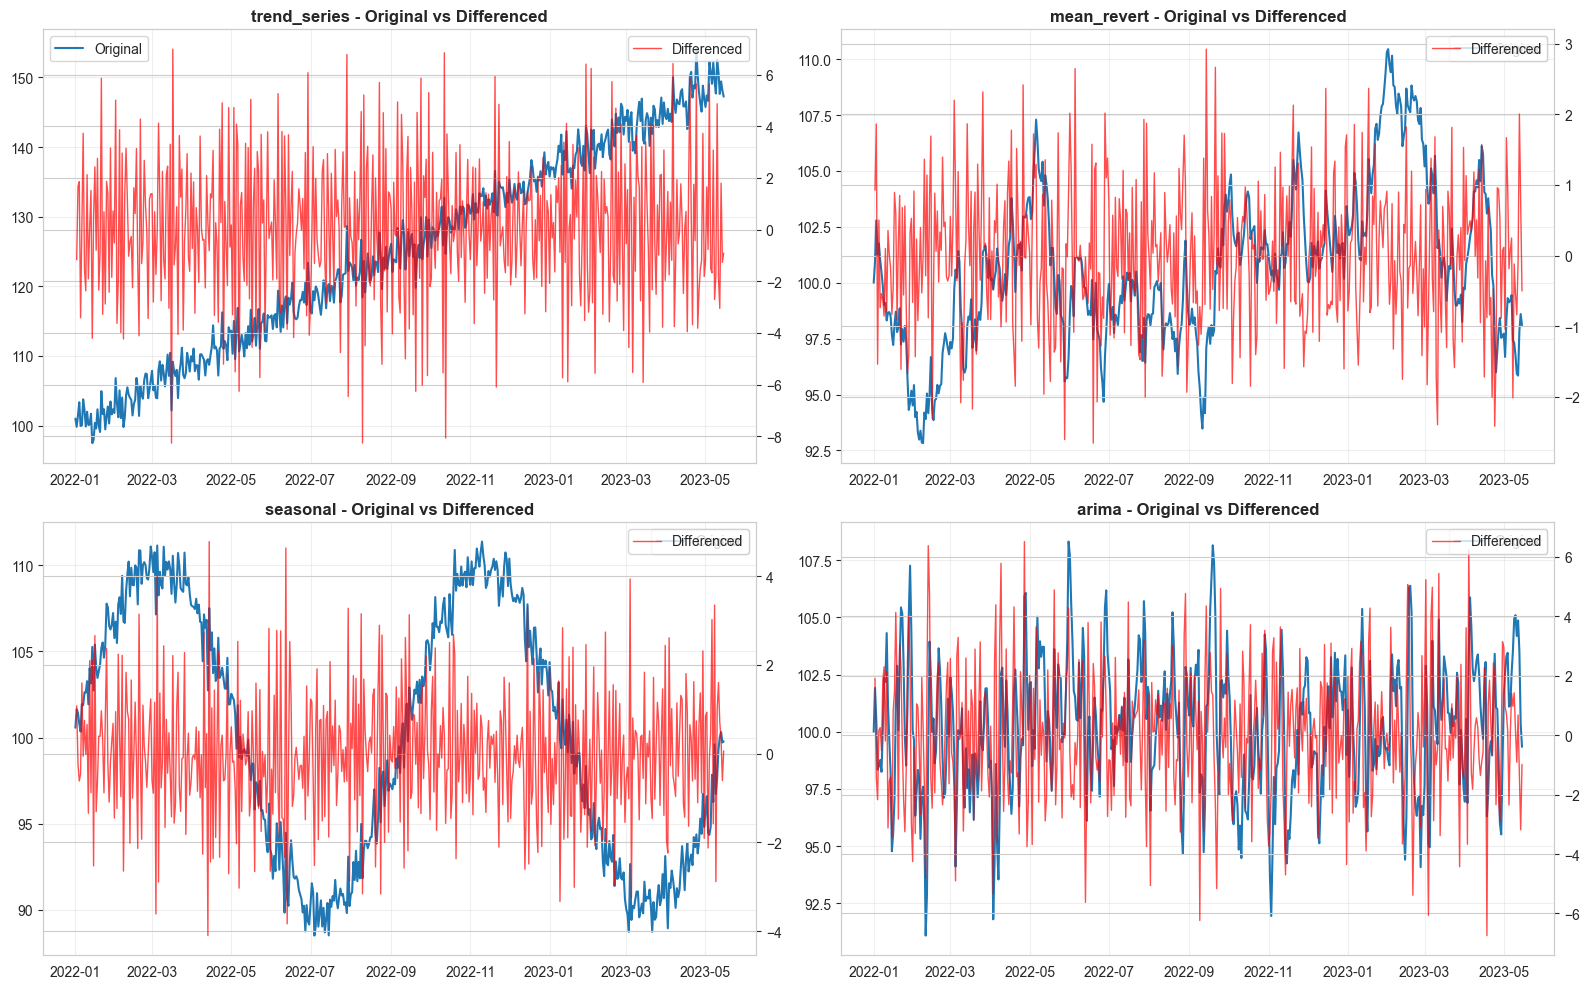

In [4]:
# Stationarity tests
def test_stationarity(series, name):
    """Perform ADF and KPSS tests"""
    # ADF Test
    adf_result = adfuller(series)
    adf_stat, adf_pvalue, _, _, adf_crit, _ = adf_result
    
    # KPSS Test
    kpss_result = kpss(series, regression='c')
    kpss_stat, kpss_pvalue, _, kpss_crit = kpss_result
    
    return {
        'Series': name,
        'ADF Stat': adf_stat,
        'ADF p-value': adf_pvalue,
        'KPSS Stat': kpss_stat,
        'KPSS p-value': kpss_pvalue,
        'Stationary (ADF)': 'Yes' if adf_pvalue < 0.05 else 'No',
        'Stationary (KPSS)': 'No' if kpss_pvalue < 0.05 else 'Yes'
    }

# Test each series
stationarity_results = []
for col in df_ts.columns:
    stationarity_results.append(test_stationarity(df_ts[col], col))

stationarity_df = pd.DataFrame(stationarity_results)
print("=" * 100)
print("STATIONARITY TEST RESULTS")
print("=" * 100)
print(stationarity_df.to_string(index=False))

# First differences to induce stationarity
df_diff = df_ts.diff().dropna()

print("\n" + "=" * 100)
print("AFTER FIRST DIFFERENCING")
print("=" * 100)
stationarity_diff = []
for col in df_diff.columns:
    stationarity_diff.append(test_stationarity(df_diff[col], col + ' (Differenced)'))

stationarity_diff_df = pd.DataFrame(stationarity_diff)
print(stationarity_diff_df.to_string(index=False))

# Visualize differences
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, col in enumerate(df_ts.columns):
    ax_orig = axes.flat[idx]
    ax_orig.plot(df_ts.index, df_ts[col], label='Original', linewidth=1.5)
    ax_orig.set_title(f'{col} - Original vs Differenced', fontweight='bold')
    ax_orig.legend()
    ax_orig.grid(alpha=0.3)
    
    # Add second axis for differences
    ax_diff = ax_orig.twinx()
    ax_diff.plot(df_diff.index, df_diff[col], label='Differenced', color='red', linewidth=1, alpha=0.7)
    ax_diff.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Autocorrelation Analysis (ACF & PACF)

Analyze autocorrelation and partial autocorrelation. ACF/PACF plots help identify ARIMA and GARCH orders.

### Why Do We Analyse ACF & PACF?

> **In plain English:** ACF asks, *"How similar is today's value to the value from 1 day ago? 2 days ago? 10 days ago?"* It measures the "memory" of the series across time.
>
> PACF asks the same question, but *controls for everything in between*. So PACF at lag 5 means: "Does day-5-ago predict today, *after removing the influence of days 1–4?*"
>
> **Everyday analogy:** Imagine conversation topics drifting between friends. ACF measures "is today's topic still related to the topic from 5 days ago?" PACF measures "is 5 days ago *directly* influencing today, or only indirectly via the days in between?"
>
> **Trading use:** If today's return has no relationship to yesterday's → random walk → nothing to model. If ACF shows a pattern → exploitable memory → an ARIMA model may capture it.

**The Core Problem:** Before fitting any model, you need to know what kind of memory the series has — does today's value depend only on yesterday's shock, or does it have a multi-period echo? ACF and PACF answer this diagnostic question.

**Practical Examples:**
- **ARIMA Model Order Selection**: ACF cuts off at lag 2 and PACF decays slowly → the series has MA(2) structure. Without these diagnostics, you'd guess the order blindly, leading to a mis-specified model and poor forecasts.
- **Mean Reversion Signal Extraction**: A stat-arb desk trading bond futures examines ACF of the basis spread. Strong negative ACF at lag 1 (anti-persistent) confirms mean-reversion behavior and justifies a fade-the-move strategy.
- **Volatility Clustering Detection**: The ACF of **squared residuals** (not the returns themselves) tests for ARCH effects. Significant ACF on squared residuals confirms that volatility clusters — justifying GARCH.

**Reading ACF/PACF Patterns at a Glance:**

| ACF Pattern | PACF Pattern | What it means | Model to use |
|------------|-------------|--------------|-------------|
| Cuts off at lag q | Slowly decays | Past *shocks* predict today | MA(q) |
| Slowly decays | Cuts off at lag p | Past *values* predict today | AR(p) |
| Both slowly decay | Both slowly decay | Both past values and shocks matter | ARMA(p,q) |
| Spikes at seasonal lag s | Spikes at lag p | Seasonal repeating pattern | SARIMA |
| **Squared** residuals ACF significant | — | Volatility clustering | GARCH needed |

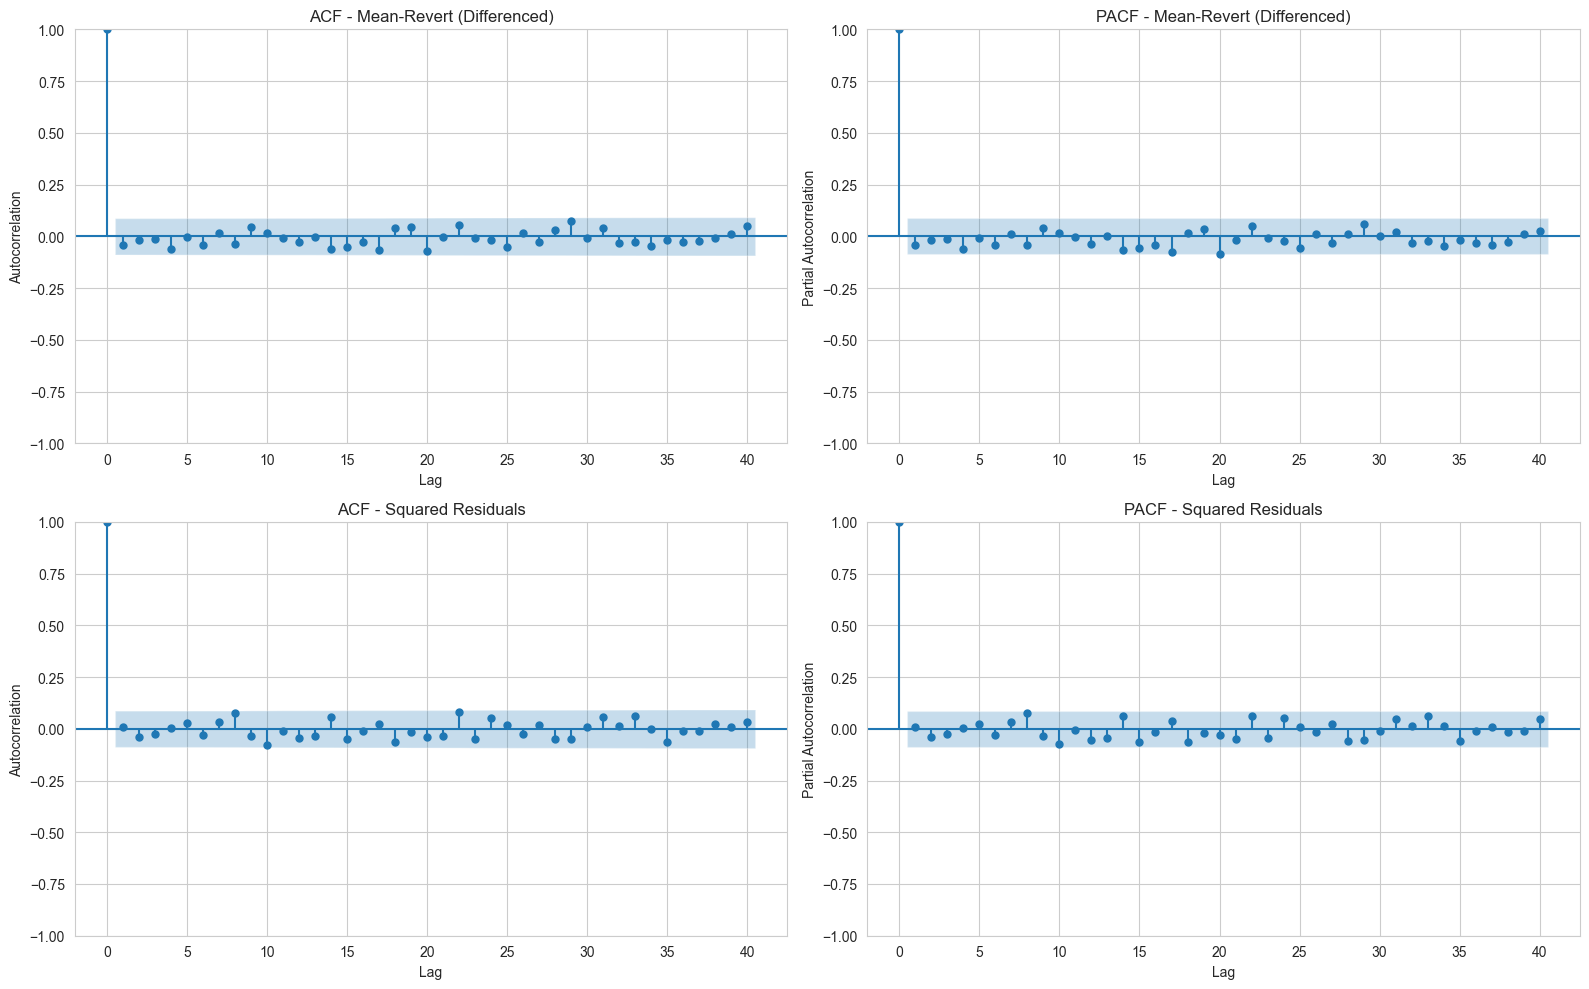

✓ Strong ACF in squared residuals suggests GARCH modeling is appropriate


In [5]:
# ACF/PACF for mean-reverting series (good example)
series_to_analyze = df_diff['mean_revert']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF
plot_acf(series_to_analyze, lags=40, ax=axes[0, 0], title='ACF - Mean-Revert (Differenced)')
axes[0, 0].set_xlabel('Lag')
axes[0, 0].set_ylabel('Autocorrelation')

# PACF
plot_pacf(series_to_analyze, lags=40, ax=axes[0, 1], title='PACF - Mean-Revert (Differenced)', method='ywm')
axes[0, 1].set_xlabel('Lag')
axes[0, 1].set_ylabel('Partial Autocorrelation')

# ACF of squared residuals (volatility clustering)
residuals = series_to_analyze - series_to_analyze.mean()
squared_residuals = residuals ** 2

plot_acf(squared_residuals, lags=40, ax=axes[1, 0], title='ACF - Squared Residuals')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('Autocorrelation')

# PACF of squared residuals
plot_pacf(squared_residuals, lags=40, ax=axes[1, 1], title='PACF - Squared Residuals', method='ywm')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

print("✓ Strong ACF in squared residuals suggests GARCH modeling is appropriate")

## 5. ARIMA Modeling

Fit ARIMA models to capture temporal dependencies. Auto-select optimal (p,d,q) parameters using information criteria.

### Why Do We Use ARIMA Modelling?

> **In plain English:** ARIMA says: "I can predict tomorrow's value by combining (a) recent past *values* (AR), (b) recent past *surprise errors* (MA), and (c) working on the *changes* in the series rather than the levels (I, for Integrated — i.e., differenced)."
>
> **Simple analogy:** Forecasting tomorrow's temperature. It will probably be similar to today's (AR), adjusted for an unpredictable surprise (MA), but we model the *change* in temperature rather than the absolute level (I — differencing to make it stationary).
>
> **ARIMA(p, d, q) in plain English:**
> - **p** = how many past *values* predict today (identified from PACF)
> - **d** = how many times we *difference* the series to make it stationary (from ADF/KPSS test)
> - **q** = how many past *surprises* influence today (identified from ACF)

**The Core Problem:** Moving averages and linear trends cannot capture complex serial dependencies in financial series. ARIMA explicitly models those dependencies in a principled, testable framework.

**Practical Examples:**
- **Short-Term Interest Rate Forecasting**: Fixed income desks model the Fed Funds Rate with ARIMA to forecast where rates will be in 3–6 months. An AR(1) component captures mean reversion toward a long-run level; the I component handles the persistence seen in rate cycles.
- **Commodity Inventory Forecasting**: Energy traders fit ARIMA to weekly storage-change data to forecast the EIA natural gas report *before it's published*, allowing pre-positioning ahead of the release.
- **Credit Card Delinquency Forecasting**: Consumer banks use ARIMA to forecast monthly charge-off rates, enabling more accurate loan-loss provisioning and capital planning.

**ARIMA(p,d,q) Components:**

$$\underbrace{\phi(B)}_{\text{AR: p past values}} \underbrace{(1-B)^d}_{\text{Differencing d times}} X_t = \underbrace{\theta(B)}_{\text{MA: q past shocks}} \varepsilon_t$$

| Parameter | What It Captures | How to Identify |
|-----------|-----------------|----------------|
| **p** (AR order) | How many past *values* predict today | PACF cuts off at lag p |
| **d** (differencing) | Makes series stationary | ADF/KPSS says "difference once (d=1)" |
| **q** (MA order) | How many past *surprises* influence today | ACF cuts off at lag q |

Using fallback ARIMA order: (1, 1, 1)

ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:            mean_revert   No. Observations:                  500
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -697.639
Date:                Sat, 30 May 2026   AIC                           1401.278
Time:                        23:40:15   BIC                           1413.916
Sample:                    01-01-2022   HQIC                          1406.238
                         - 05-15-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9571      0.018     53.768      0.000       0.922       0.992
ma.L1         -0.9950      0.008   -125.307      0.000      -1.011      

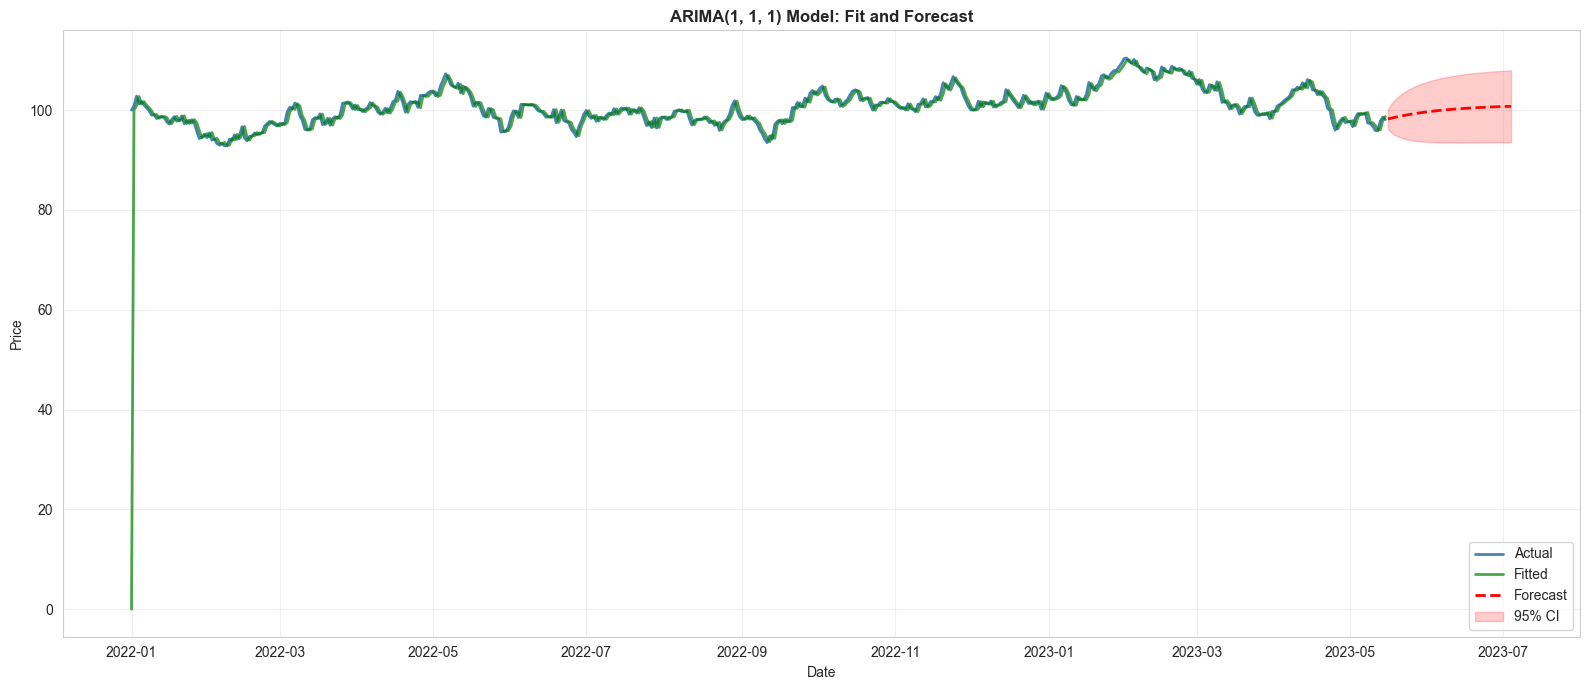

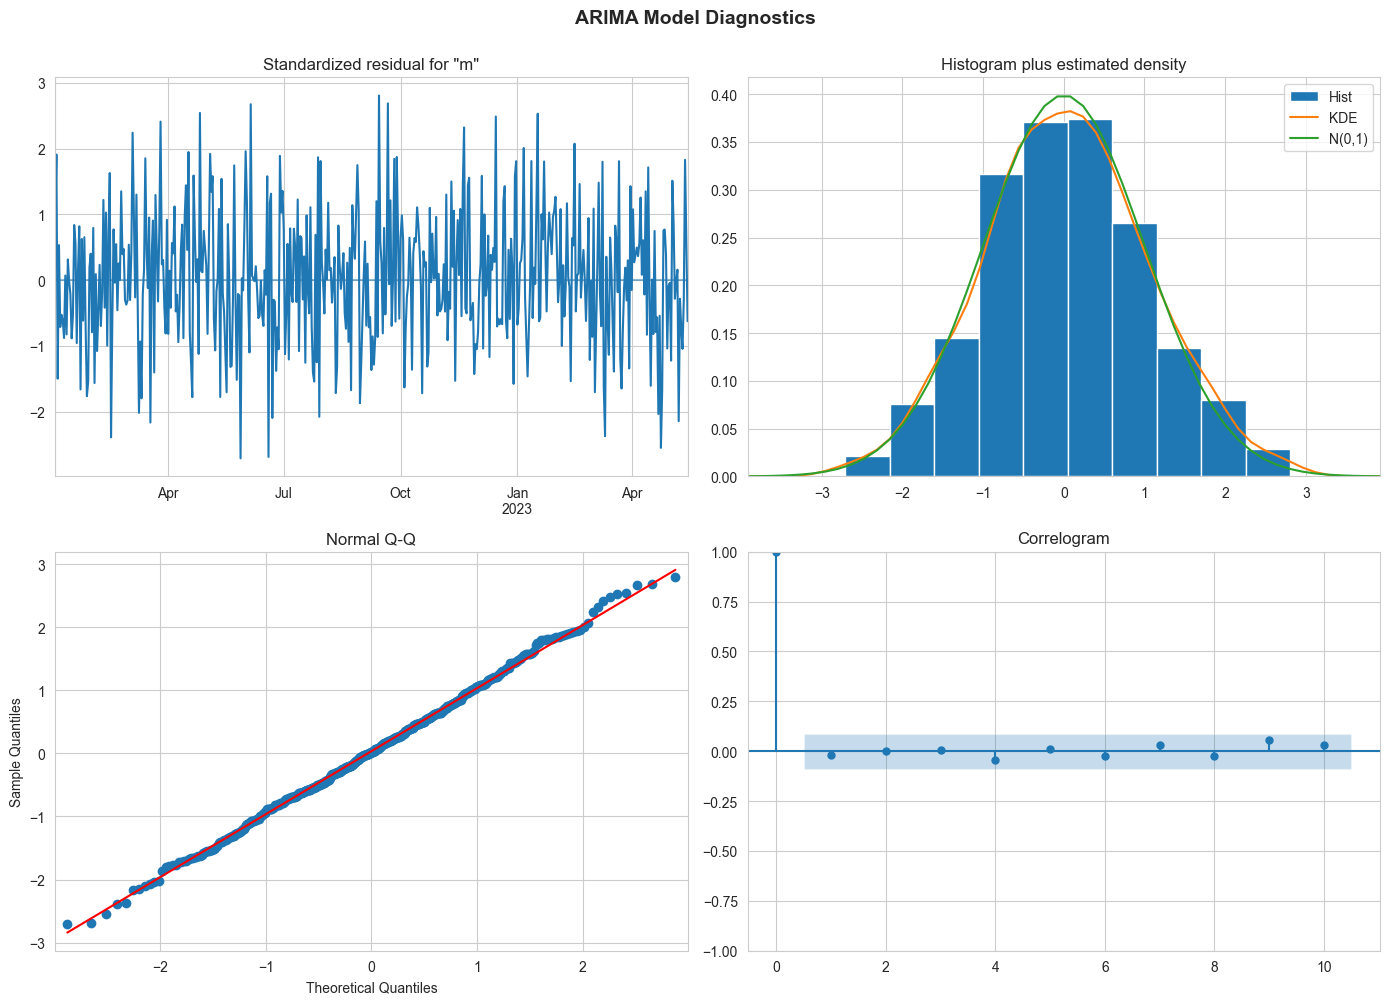

In [6]:
# Select optimal ARIMA order
series = df_ts['mean_revert']

try:
    auto_order = arima_order_select_ic(series, max_p=5, max_d=2, max_q=5, ic='aic')
    best_order = auto_order['aic'][0]
    print(f"Auto-selected ARIMA order: {best_order}")
except:
    best_order = (1, 1, 1)
    print(f"Using fallback ARIMA order: {best_order}")

# Fit ARIMA model
arima_model = ARIMA(series, order=best_order)
arima_fit = arima_model.fit()

print("\n" + "=" * 80)
print("ARIMA MODEL SUMMARY")
print("=" * 80)
print(arima_fit.summary())

# In-sample fit and forecast
forecast_steps = 50
forecast = arima_fit.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()
forecast_values = forecast.predicted_mean

# Plot fit and forecast
fig, ax = plt.subplots(figsize=(16, 7))

# Original data
ax.plot(series.index, series.values, label='Actual', linewidth=2, color='steelblue')

# Fitted values
ax.plot(series.index, arima_fit.fittedvalues, label='Fitted', linewidth=2, color='green', alpha=0.7)

# Forecast
forecast_idx = pd.date_range(start=series.index[-1], periods=forecast_steps+1, freq='D')[1:]
ax.plot(forecast_idx, forecast_values, label='Forecast', linewidth=2, color='red', linestyle='--')

# Confidence intervals
ax.fill_between(forecast_idx, 
                forecast_ci.iloc[:, 0], 
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='red', label='95% CI')

ax.set_title(f'ARIMA{best_order} Model: Fit and Forecast', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Model diagnostics
arima_fit.plot_diagnostics(figsize=(14, 10))
plt.suptitle('ARIMA Model Diagnostics', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. GARCH Modeling for Volatility Forecasting

Fit GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models to capture time-varying volatility.

### Why Do We Use GARCH for Volatility Forecasting?

> **In plain English:** ARIMA models the *average return* of a series — it tells you where prices are heading. GARCH models the *riskiness* of that series — it tells you how widely prices might swing around that average. Risk is not constant: some weeks are calm, others are turbulent.
>
> **Analogy:** Think of the weather. After a storm, the weather stays unsettled and hard to predict for a few days. After a market crash, volatility stays elevated for weeks. GARCH captures this *"volatility begets volatility"* effect — formally called **volatility clustering**.
>
> **Why does this matter to you?**
> - If you're sizing a position, you need to know if you're in a calm or turbulent regime.
> - If you're pricing options, volatility is the key input. Using yesterday's long-run average when the market is in a spike will lead to badly mispriced options.
> - Regulators (Basel III/IV) require banks to use GARCH-style volatility in daily VaR calculations.

**The Core Problem:** ARIMA models the conditional mean of returns, but the variance of returns is not constant — it clusters in high-volatility episodes and contracts in calm periods. GARCH explicitly models this time-varying variance.

**Practical Examples:**
- **Options Market Making**: Every market maker at a major derivatives desk uses GARCH to estimate near-term realized volatility. By comparing GARCH-implied vol against market implied vol (IV), traders identify when options are mispriced — buying cheap IV when GARCH forecasts suggest a vol spike.
- **Daily VaR Calculation**: Under the Basel Internal Models Approach, banks calculate 10-day 99% VaR using GARCH conditional volatility rather than constant historical vol. When GARCH detects a spike, VaR increases automatically and more capital is held in reserve.
- **Risk Parity Rebalancing**: Funds like Bridgewater's All Weather use rolling GARCH estimates to scale positions. When equity GARCH vol doubles, the equity allocation is halved — done daily, requiring a fast real-time vol model.

**GARCH(1,1) — The Most Common Specification:**

$$\sigma_t^2 = \underbrace{\omega}_{\text{floor}} + \underbrace{\alpha\,\varepsilon_{t-1}^2}_{\text{reaction to yesterday's shock}} + \underbrace{\beta\,\sigma_{t-1}^2}_{\text{persistence of yesterday's vol}}$$

| Parameter | Meaning | Typical Value |
|-----------|---------|---------------|
| ω (omega) | Long-run variance floor — vol never falls to zero | Small positive |
| α (alpha) | How strongly vol reacts to new shocks | 0.05 – 0.15 |
| β (beta) | How persistent vol is once it spikes | 0.80 – 0.95 |
| α + β < 1 | Stationarity condition — vol must eventually mean-revert | Must hold |

> **Key insight:** High β means volatility is *persistent* — once it spikes after a crash, it stays elevated for days or weeks. This is exactly what we see in real markets.

GARCH(1,1) MODEL SUMMARY
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            mean_revert   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -699.900
Distribution:                  Normal   AIC:                           1407.80
Method:            Maximum Likelihood   BIC:                           1424.65
                                        No. Observations:                  499
Date:                Sat, May 30 2026   Df Residuals:                      498
Time:                        23:40:25   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.5157e-03  4.475e-

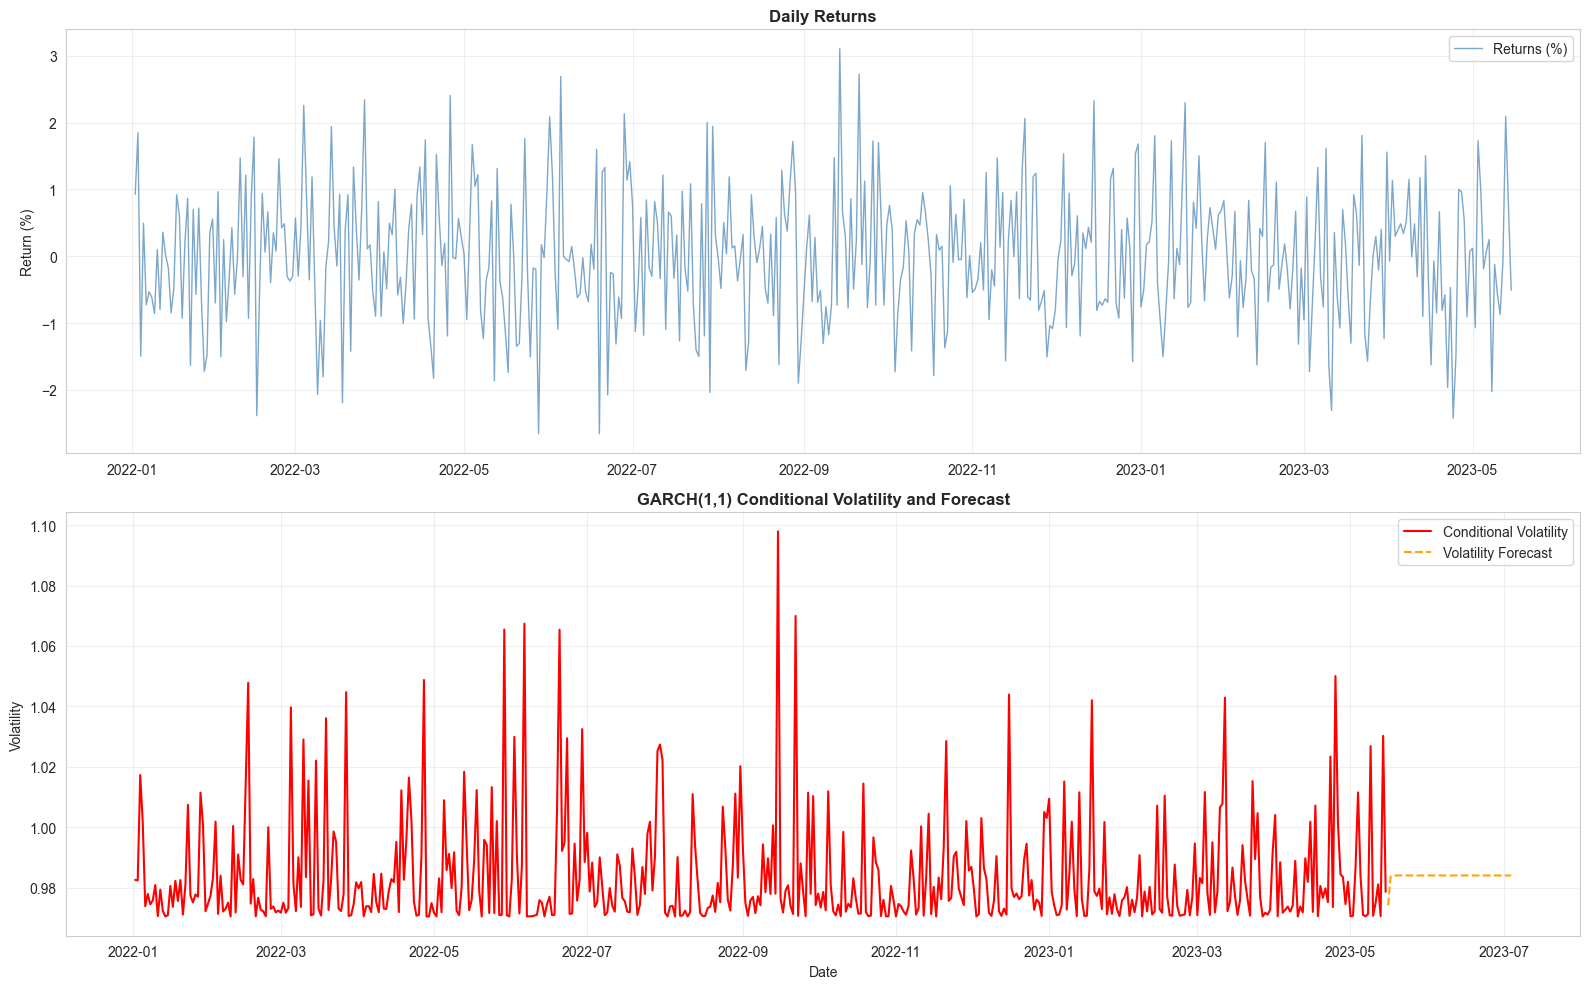


Current Volatility: 0.9787%
Avg Volatility (10-day): 0.9847%


In [7]:
# Calculate returns for GARCH modeling
returns = df_ts['mean_revert'].pct_change().dropna() * 100  # In percentage

# Fit GARCH(1,1) model
garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp='off')

print("=" * 80)
print("GARCH(1,1) MODEL SUMMARY")
print("=" * 80)
print(garch_fit.summary())

# Get conditional volatility
garch_volatility = garch_fit.conditional_volatility

# Forecast volatility
garch_forecast = garch_fit.forecast(horizon=50)
garch_volatility_forecast = garch_forecast.variance.iloc[-1, :].values ** 0.5

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot returns
ax = axes[0]
ax.plot(returns.index, returns.values, label='Returns (%)', linewidth=1, color='steelblue', alpha=0.7)
ax.set_title('Daily Returns', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.grid(alpha=0.3)
ax.legend()

# Plot conditional volatility and forecast
ax = axes[1]
ax.plot(garch_volatility.index, garch_volatility.values, label='Conditional Volatility', 
        linewidth=1.5, color='red')

forecast_idx = pd.date_range(start=garch_volatility.index[-1], periods=51, freq='D')[1:]
ax.plot(forecast_idx, garch_volatility_forecast, label='Volatility Forecast', 
        linewidth=1.5, color='orange', linestyle='--')

ax.set_title('GARCH(1,1) Conditional Volatility and Forecast', fontweight='bold')
ax.set_ylabel('Volatility')
ax.set_xlabel('Date')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nCurrent Volatility: {garch_volatility.iloc[-1]:.4f}%")
print(f"Avg Volatility (10-day): {garch_volatility.tail(10).mean():.4f}%")

## 7. Trend & Seasonality Decomposition

Decompose time series into trend, seasonality, and residual components using classical decomposition.

### Why Do We Decompose Trend & Seasonality?

> **In plain English:** Many financial series have a predictable rhythm baked in — year-end effects, quarterly earnings, summer energy demand. Decomposition *peels apart* this predictable structure from the genuine random noise underneath.
>
> **Analogy:** A coffee shop's daily sales have a pattern: busy Monday mornings, slow Tuesday afternoons, a big spike every December. "Decomposing" the sales separates the predictable weekly/yearly pattern from unexpected days (a local event nearby, a broken espresso machine). The unexplained part is what you actually want to investigate.
>
> **The three pieces you get:**
> - 🔵 **Trend** — the slow, long-run direction (interest rates rising over a decade)
> - 🟠 **Seasonal** — the predictable repeating cycle (gas prices up every summer)
> - 🔴 **Residual** — what's genuinely unexplained: surprising moves, anomalies, potential trading signals

**The Core Problem:** If a time series has a strong trend or seasonal pattern, any model fitted on the raw series will conflate the expected structure with genuine noise. Decomposition separates what is "predictable calendar effect" from what is a true signal.

**Practical Examples:**
- **Retail Sales Forecasting**: Amazon and Walmart forecast inventory weeks ahead. Raw monthly sales have massive December spikes and January drops. Without STL decomposition, an ARIMA model treats every December spike as a "surprise" — overestimating forecast uncertainty and causing costly inventory errors.
- **Energy Market Trading**: Natural gas futures exhibit strong winter/summer seasonality. Traders decompose 5-year price histories to isolate the secular trend (supply/demand shifts) from seasonal cycles, enabling accurate pricing of seasonal supply contracts.
- **Anomaly Detection in Market Data**: After decomposing a series, the *residual* component represents unexplained variation. Residuals > 3σ from their mean are anomalies: unexpected corporate events, data errors, or genuine market dislocations worth investigating.

**STL Decomposition Formula:**

$$Y_t = T_t + S_t + R_t$$

| Component | Symbol | What it represents |
|-----------|--------|-------------------|
| Trend | $T_t$ | Slow-moving structural direction |
| Seasonal | $S_t$ | Predictable, repeating cycle |
| Residual | $R_t$ | Genuinely unexplained variation — the signal worth trading |

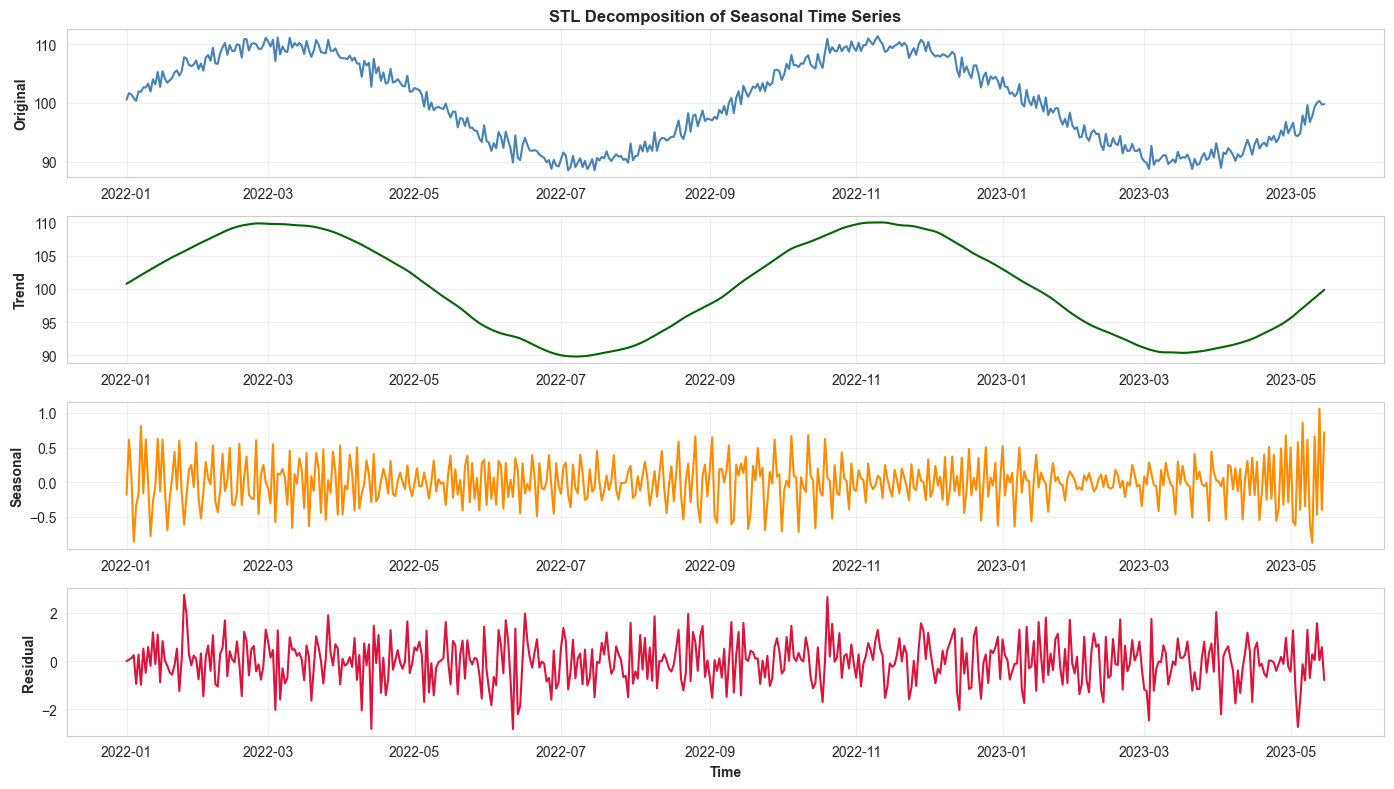

Original Series Variance : 51.0167
Trend    Variance         : 49.0847 (96.21% of total)
Seasonal Variance         : 0.0960 (0.19% of total)
Residual Variance         : 0.8092 (1.59% of total)

How to read this:
  • High Seasonal %  → the series is mostly driven by repeating cycles
  • High Residual %  → lots of unexplained noise — harder to forecast
  • Low Residual %   → the trend + seasonal pattern explains most of the series


In [8]:
from statsmodels.tsa.seasonal import STL

# Use the seasonal series for decomposition (most interesting)
seasonal_series = df_ts['seasonal']   # ← df_ts, not data

# Apply STL decomposition (Seasonal and Trend decomposition using Loess)
# robust=True handles outliers better
stl = STL(seasonal_series, seasonal=13, trend=27, robust=True)
result = stl.fit()

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 8))

# Original series
axes[0].plot(seasonal_series.index, seasonal_series.values, color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[0].set_title('STL Decomposition of Seasonal Time Series', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend component
axes[1].plot(result.trend.index, result.trend.values, color='darkgreen', linewidth=1.5)
axes[1].set_ylabel('Trend', fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Seasonal component
axes[2].plot(result.seasonal.index, result.seasonal.values, color='darkorange', linewidth=1.5)
axes[2].set_ylabel('Seasonal', fontsize=10, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Residual component
axes[3].plot(result.resid.index, result.resid.values, color='crimson', linewidth=1.5)
axes[3].set_ylabel('Residual', fontsize=10, fontweight='bold')
axes[3].set_xlabel('Time', fontsize=10, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print decomposition variance
var_original = seasonal_series.var()
var_trend    = result.trend.var()
var_seasonal = result.seasonal.var()
var_residual = result.resid.var()

print(f"Original Series Variance : {var_original:.4f}")
print(f"Trend    Variance         : {var_trend:.4f} ({100*var_trend/var_original:.2f}% of total)")
print(f"Seasonal Variance         : {var_seasonal:.4f} ({100*var_seasonal/var_original:.2f}% of total)")
print(f"Residual Variance         : {var_residual:.4f} ({100*var_residual/var_original:.2f}% of total)")
print()
print("How to read this:")
print("  • High Seasonal %  → the series is mostly driven by repeating cycles")
print("  • High Residual %  → lots of unexplained noise — harder to forecast")
print("  • Low Residual %   → the trend + seasonal pattern explains most of the series")

## 8. Mean Reversion Analysis & Half-Life Estimation

Test for mean reversion and estimate the half-life of mean-reverting processes using Ornstein-Uhlenbeck framework.

### Why Do We Estimate Mean Reversion & Half-Life?

> **In plain English:** Some financial series behave like a rubber band — the further they stretch from their average, the stronger the pull back. The **half-life** answers the practical question: *"How many days, on average, does it take for the series to cover half the distance back to its mean?"*
>
> **Why half-life matters for trading:**
> - Half-life of **3 days** → short-term strategy: enter the trade, exit 3 days later
> - Half-life of **60 days** → suitable only for a long-term allocation, not active trading
> - **No mean reversion detected** → don't fade the move! The series is a random walk.
>
> **How we measure mean reversion — the Hurst Exponent:**
> | Hurst Exponent H | Interpretation |
> |------------------|---------------|
> | H < 0.5 | **Mean-reverting** — overshoots get corrected |
> | H = 0.5 | **Random walk** — no predictable pattern |
> | H > 0.5 | **Trending** — past direction continues |

**The Core Problem:** Knowing that a series "tends to revert" is not enough to trade it. You need to know *how fast* it reverts — the half-life. A spread that takes 200 days to revert is untradable; one that takes 5 days is a high-frequency edge.

**Practical Examples:**
- **Pairs Trading Holding Period**: A quant finds the LVMH/Kering luxury goods spread has a 12-day half-life. This means the fund holds for ~1 half-life (12 days) before expecting to capture 50% of the profit — directly setting turnover, transaction cost budget, and required Sharpe ratio.
- **Fixed Income Relative Value**: Bond traders use Ornstein-Uhlenbeck (OU) half-life to model yield curve anomalies. A 2s10s spread with a 30-day half-life supports a carry trade; a 3-day half-life supports an intraday strategy.
- **FX & Purchasing Power Parity**: Exchange rates mean-revert toward PPP equilibrium with half-lives of 3–5 years. This explains why short-term PPP-based FX trades don't work but long-term sovereign wealth fund allocation does.
- **Stat Arb Signal Expiry**: A quant sets signal expiry = 1 half-life. Signals that haven't converted to profit within 1 half-life are closed at market — cutting losers before the spread drifts further away.

**Ornstein-Uhlenbeck (OU) Process — The Mean Reversion Model:**

$$dX_t = \underbrace{\theta}_{\text{reversion speed}}(\underbrace{\mu}_{\text{long-run mean}} - X_t)\,dt + \sigma\,dW_t$$

$$\text{Half-Life} = \frac{\ln(2)}{\theta}$$

| Parameter | Meaning | Trading Implication |
|-----------|---------|---------------------|
| θ (theta) | Reversion speed | Higher θ → faster revert → shorter holding period |
| μ (mu) | Long-run equilibrium | The entry/exit signal reference point |
| Half-life | $\ln(2) / \theta$ | Average days to recover 50% of a deviation |

Hurst Exponent : 0.3307
Interpretation : Mean-Reverting  ← price snaps back; spread/pairs trading applies

OU Mean Reversion Speed β : -0.040798
Half-Life (days)          : 16.64

Interpretation: On average, a price deviation takes 16.6 days to
                close 50% of the gap back to the long-run mean.
                → A strategy would target a ~17-day holding period.


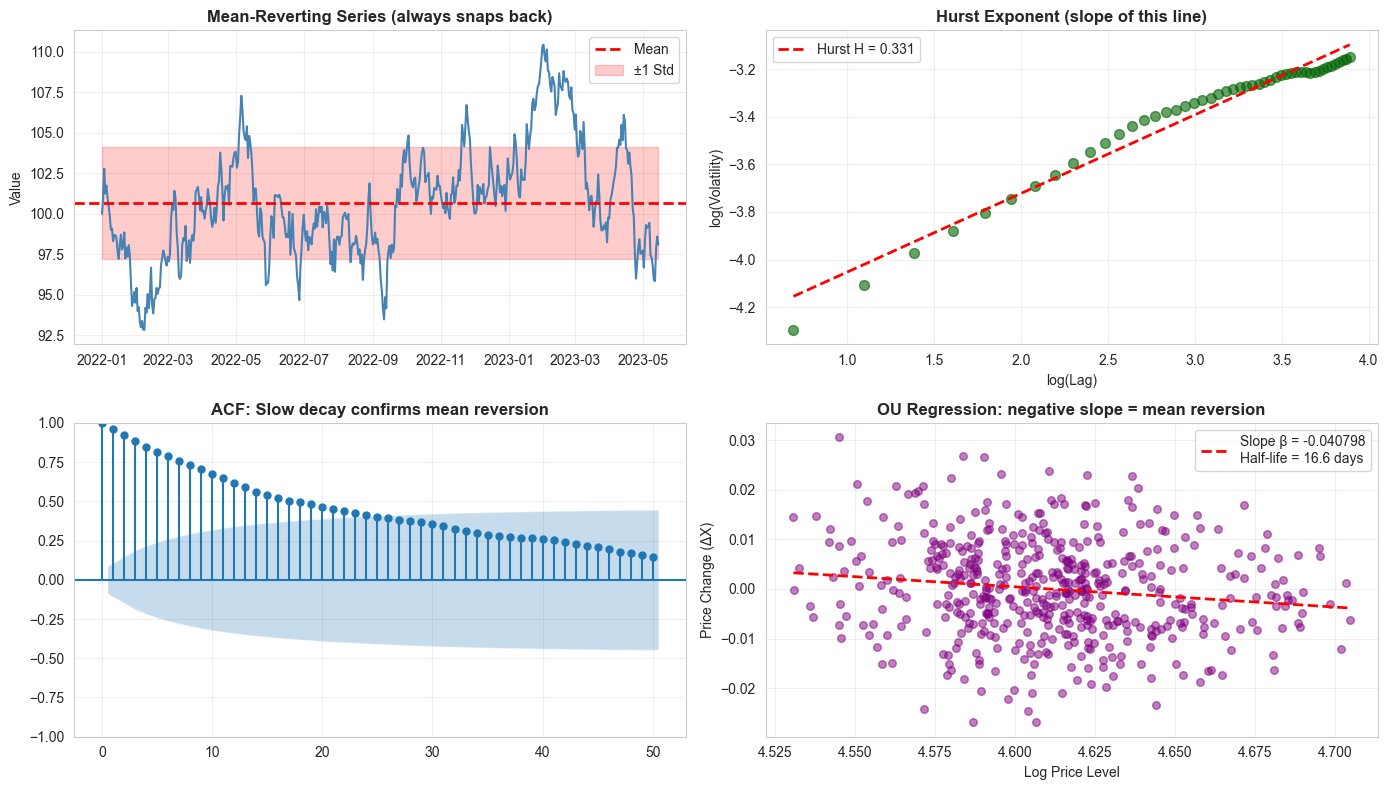

In [10]:
from scipy import stats as sp_stats

# Use log-price of the mean-reverting series  (df_ts, not data)
log_price  = np.log(df_ts['mean_revert'])
price_diff = log_price.diff().dropna()

# ─────────────────────────────────────────────────────────────────────────────
# Test 1: Hurst Exponent (variance scaling method)
# H < 0.5 → mean-reverting   H = 0.5 → random walk   H > 0.5 → trending
# Key: use lag-k differences: X[t] - X[t-lag], NOT np.diff(X, lag)
# ─────────────────────────────────────────────────────────────────────────────
def calculate_hurst_exponent(timeseries, lags_range=None):
    """Calculate Hurst Exponent via variance scaling (lag-k differences)."""
    if lags_range is None:
        lags_range = range(2, 50)
    lags = []
    tau  = []
    ts = np.array(timeseries)
    for lag in lags_range:
        # lag-k differences: distance between observations k steps apart
        delta = ts[lag:] - ts[:-lag]
        s_lag = np.sqrt(np.mean(delta**2))
        lags.append(lag)
        tau.append(s_lag)
    tau  = np.array(tau)
    lags = np.array(lags)
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0], poly, lags, tau

hurst_exp, poly, lags, tau = calculate_hurst_exponent(log_price.values)
print(f"Hurst Exponent : {hurst_exp:.4f}")
if hurst_exp < 0.45:
    regime = "Mean-Reverting  ← price snaps back; spread/pairs trading applies"
elif hurst_exp > 0.55:
    regime = "Trending        ← use momentum / trend-following"
else:
    regime = "Random Walk     ← near 0.5, no reliable edge from mean reversion"
print(f"Interpretation : {regime}")

# ─────────────────────────────────────────────────────────────────────────────
# Test 2: Ornstein-Uhlenbeck Half-Life
# Regress ΔX_t on X_{t-1}: ΔX = α + β·X  →  θ = -β  →  half-life = ln2/θ
# ─────────────────────────────────────────────────────────────────────────────
def estimate_ou_halflife(timeseries):
    """Return half_life, beta (reversion coeff), and OLS params (intercept, slope)."""
    X            = timeseries[:-1].values
    y            = timeseries.diff().dropna().values
    X_with_const = np.column_stack([np.ones(len(X)), X])
    params, _, _, _ = np.linalg.lstsq(X_with_const, y, rcond=None)
    beta         = params[1]
    if beta >= 0:
        print("Warning: β ≥ 0 → no mean reversion detected (or non-stationary).")
        half_life = np.nan
    else:
        half_life = -np.log(2) / np.log(1 + beta)
    return half_life, beta, params

half_life, beta, ou_params = estimate_ou_halflife(log_price)

print(f"\nOU Mean Reversion Speed β : {beta:.6f}")
print(f"Half-Life (days)          : {half_life:.2f}")
print()
if not np.isnan(half_life):
    print(f"Interpretation: On average, a price deviation takes {half_life:.1f} days to")
    print(f"                close 50% of the gap back to the long-run mean.")
    print(f"                → A strategy would target a ~{half_life:.0f}-day holding period.")

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation — 4 panels
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: Mean-reverting series + mean + ±1σ band
mr_series = df_ts['mean_revert']
mu_mr     = mr_series.mean()
sd_mr     = mr_series.std()

axes[0, 0].plot(df_ts.index, mr_series.values, color='steelblue', linewidth=1.5)
axes[0, 0].axhline(y=mu_mr, color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].fill_between(df_ts.index,
                         mu_mr - sd_mr, mu_mr + sd_mr,
                         alpha=0.2, color='red', label='±1 Std')
axes[0, 0].set_title('Mean-Reverting Series (always snaps back)', fontweight='bold')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Hurst log-log plot
axes[0, 1].scatter(np.log(lags), np.log(tau), alpha=0.6, s=50, color='darkgreen')
fitted_line = np.poly1d(poly)(np.log(lags))
axes[0, 1].plot(np.log(lags), fitted_line, 'r--', linewidth=2,
                label=f'Hurst H = {hurst_exp:.3f}')
axes[0, 1].set_xlabel('log(Lag)')
axes[0, 1].set_ylabel('log(Volatility)')
axes[0, 1].set_title('Hurst Exponent (slope of this line)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: ACF decay
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(mr_series.values, lags=50, ax=axes[1, 0])
axes[1, 0].set_title('ACF: Slow decay confirms mean reversion', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: OU regression — ΔX vs X level
axes[1, 1].scatter(log_price[:-1], log_price.diff().dropna(),
                   alpha=0.5, s=30, color='purple')
x_line = np.array([log_price.min(), log_price.max()])
y_line = ou_params[0] + ou_params[1] * x_line    # ← uses ou_params returned from function
axes[1, 1].plot(x_line, y_line, 'r--', linewidth=2,
                label=f'Slope β = {beta:.6f}\nHalf-life = {half_life:.1f} days')
axes[1, 1].set_xlabel('Log Price Level')
axes[1, 1].set_ylabel('Price Change (ΔX)')
axes[1, 1].set_title('OU Regression: negative slope = mean reversion', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Co-Integration Analysis

Test for co-integration between multiple assets using Johansen test (foundation for pairs trading).

### Why Do We Test for Co-integration?

> **In plain English:** Two stocks might each wander freely on their own (non-stationary) — drifting up or down without limit. But their *relationship* can still be stable over time. Co-integration means the two series are tethered together: they can't drift too far apart for too long.
>
> **The dog-on-a-leash analogy:** Imagine a dog walking its owner in a park. The dog wanders left and right, the owner walks roughly forward. Individually, both paths are unpredictable. But the *distance between them* is bounded by the leash — it's stationary. When the gap gets big → the leash pulls. That leash is the co-integrating relationship.
>
> **Why correlation alone is not enough:**
> - Correlation can be 0.9 today and 0.1 next year — it breaks down in regime changes.
> - Co-integration tests whether the *long-run structural equilibrium* holds statistically.
> - A high correlation tells you they often move together. Co-integration tells you they *must* stay together.

**The Core Problem:** Two non-stationary (drifting) price series cannot be traded on correlation alone — correlation breaks down constantly. Co-integration identifies pairs that share a long-run equilibrium, meaning their spread is stationary even though each series individually is not.

**Practical Examples:**
- **Classic Pairs Trade**: Royal Dutch Shell and Shell Transport — two share classes of the same company, listed on different exchanges. Co-integration exists because arbitrageurs enforce the pricing relationship. When the spread widens, quants short the expensive leg and buy the cheap one, profiting as it converges.
- **CDS vs. Bond Spread**: Investment-grade credit desks trade the basis between CDS spreads and bond spreads. Both price the same credit risk, so they're co-integrated. When the basis widens during a market dislocation → convergence trade.
- **Currency Triangular Arbitrage**: EUR/USD, GBP/USD, and EUR/GBP are co-integrated by no-arbitrage constraints. FX quants use Johansen tests to verify the co-integrating rank and trade deviations algorithmically.

**Co-Integration vs. Correlation:**

| Measure | What It Tests | Stable Over Time? | Use Case |
|---------|--------------|------------------|----------|
| **Correlation** | Linear co-movement at a point in time | No — breaks in crises | Marketing materials, not trading |
| **Co-integration** | Shared long-run stochastic trend | Yes — structural relationship | Real pairs trading |

**Johansen Test Interpretation:**

| Test Result | Meaning | Action |
|------------|---------|--------|
| Rank = 0 | No co-integrating relationship | Don't trade this pair |
| Rank = 1 | One co-integrating vector (classic pairs trade) | Trade the stationary spread |
| Rank ≥ 2 | Multiple relationships | Portfolio of 3+ assets possible |

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Use the two most structurally related series from df_ts
series1 = df_ts['trend_series']  # slow-trending series
series2 = df_ts['seasonal']  # another non-stationary series

# Combine into a DataFrame for the Johansen test
pair_df = pd.DataFrame({
    'series1': series1.values,
    'series2': series2.values,
}, index=df_ts.index)   # ← df_ts.index, not data.index

print("=== Johansen Co-integration Test ===")
print("Null hypothesis: NO co-integrating relationship exists between the two series.")
print()

# det_order = 0 → constant only (most common for price series)
# k_ar_diff = 1 → one lag difference
result = coint_johansen(pair_df, det_order=0, k_ar_diff=1)

# Interpret trace statistics (test rank = 0, then rank ≤ 1)
trace_stat  = result.lr1       # Trace statistics
trace_cvals = result.cvt       # Critical values: columns are 90%, 95%, 99%

print("Trace Statistic Test:")
print("-" * 55)
for i in range(len(trace_stat)):
    ts   = trace_stat[i]
    cv95 = trace_cvals[i, 1]    # 95% critical value
    flag = "✓ REJECT H₀ (co-integration exists)" if ts > cv95 else "✗ FAIL TO REJECT H₀"
    print(f"  H₀: rank ≤ {i}  |  Stat: {ts:.4f}  |  CV(95%): {cv95:.4f}  |  {flag}")

print()

# Co-integrating vector (beta) — weights to form the stationary spread
beta_vector = result.evec[:, 0]
print(f"Co-integrating Vector  : [{beta_vector[0]:.4f}, {beta_vector[1]:.4f}]")

# Compute the spread = β₁·S₁ + β₂·S₂
spread = beta_vector[0] * pair_df['series1'] + beta_vector[1] * pair_df['series2']
spread = spread - spread.mean()

print()
print(f"Spread mean            : {spread.mean():.4f}")
print(f"Spread std             : {spread.std():.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Generate trading signals from Bollinger Bands on the spread
# ─────────────────────────────────────────────────────────────────────────────
window = 30
spread_ma  = spread.rolling(window).mean()
spread_std = spread.rolling(window).std()
z_score    = (spread - spread_ma) / spread_std

# Signals: short spread when z > +2, long spread when z < -2
signals = pd.DataFrame({
    'spread'     : spread,
    'z_score'    : z_score,
    'upper_band' : spread_ma + 2 * spread_std,
    'lower_band' : spread_ma - 2 * spread_std,
}, index=df_ts.index)

signals['signal'] = 0
signals.loc[z_score >  2.0, 'signal'] = -1   # short spread
signals.loc[z_score < -2.0, 'signal'] =  1   # long spread

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Original series
axes[0].plot(df_ts.index, pair_df['series1'].values,  label='Series 1', color='steelblue', linewidth=1.5)
axes[0].plot(df_ts.index, pair_df['series2'].values,  label='Series 2', color='darkorange', linewidth=1.5)
axes[0].set_title('Two Individual Series (each non-stationary on its own)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Stationary spread
axes[1].plot(df_ts.index, spread.values,              label='Spread', color='purple', linewidth=1.5)
axes[1].plot(df_ts.index, signals['upper_band'].values,'r--', alpha=0.7, label='+2σ')
axes[1].plot(df_ts.index, signals['lower_band'].values,'g--', alpha=0.7, label='-2σ')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_title('Co-integrated Spread (stationary — it reverts!)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Trading signals
axes[2].plot(df_ts.index, z_score.values, color='navy', linewidth=1.5, label='Z-Score')
axes[2].axhline( 2.0, color='red',   linestyle='--', linewidth=1.5, label='+2σ Threshold (SELL)')
axes[2].axhline(-2.0, color='green', linestyle='--', linewidth=1.5, label='-2σ Threshold (BUY)')
axes[2].axhline( 0.0, color='black', linestyle='-',  linewidth=0.8)
axes[2].fill_between(df_ts.index, z_score.values, 2.0,
                      where=(z_score > 2.0),  alpha=0.3, color='red',   label='Short Signal')
axes[2].fill_between(df_ts.index, z_score.values, -2.0,
                      where=(z_score < -2.0), alpha=0.3, color='green', label='Long Signal')
axes[2].set_title('Trading Signals (Z-Score of Co-integrated Spread)', fontweight='bold')
axes[2].set_xlabel('Time')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_short = (signals['signal'] == -1).sum()
n_long  = (signals['signal'] ==  1).sum()
print(f"\nSignal Summary:")
print(f"  Long signals  (z < -2): {n_long:>4d} days  → spread is unusually cheap, buy")
print(f"  Short signals (z >  2): {n_short:>4d} days  → spread is unusually expensive, sell")

KeyError: 'trend'

## 10. Mean Reversion Trading Strategy

Implement a simple mean reversion trading strategy using Bollinger Bands and evaluate performance metrics.

### Why Do We Need a Concrete Trading Strategy?

> **In plain English:** Statistical analysis alone doesn't make money — it only tells you *what is happening* in the data. A trading strategy translates that observation into specific, rule-based actions: when to buy, when to sell, how much to risk, and when to give up.
>
> **Bollinger Bands** are the classic mean-reversion signal:
> - Compute a rolling average (the "normal" price level)
> - Compute a rolling standard deviation (how wide the "normal" range is)
> - **Upper band** = average + 2σ → price is unusually high → likely to fall → **SELL**
> - **Lower band** = average − 2σ → price is unusually low → likely to rise → **BUY**
> - Then wait for the price to revert to the average → take profit

**The Core Problem:** Statistical analysis alone doesn't generate profit — you need a formalized, rules-based strategy that translates statistical observations into trade entries, exits, position sizing, and performance measurement.

**Practical Examples:**
- **Renaissance Technologies Medallion Fund**: The most profitable hedge fund in history (avg 66% gross return 1988–2018) is rooted in statistical mean-reversion. Bollinger-Band-style entry/exit signals on hundreds of assets simultaneously are the conceptual foundation.
- **ETF Statistical Arbitrage**: The premium/discount of an ETF to its NAV is a mean-reverting spread. When the Bollinger Band level is breached, arb desks trade to keep ETF prices tethered to their NAV.
- **Systematic Fixed Income**: Interest rate spread desks at major banks run Bollinger-Band-type strategies on yield curve spreads (2s10s, 5s30s). When the spread breaches 2σ from its 60-day mean, a trade is initiated with a pre-defined risk limit.

**Three Questions Every Strategy Must Answer:**

> 1. **Did it make money?** → Total return vs buy-and-hold
> 2. **Was the risk worth taking?** → Sharpe / Sortino ratio
> 3. **What's the worst it's ever been?** → Max drawdown (the gut-check test)

**Performance Metrics Decoded:**

| Metric | What It Measures | Good Value |
|--------|-----------------|-----------|
| **Total Return** | Absolute profit over the period | Beat buy-and-hold |
| **Sharpe Ratio** | Return per unit of total risk | > 1.0 good, > 2.0 excellent |
| **Sortino Ratio** | Return per unit of *downside* risk only | Higher than Sharpe = low downside |
| **Max Drawdown** | Worst peak-to-trough loss | < 20% (institutional), < 10% (conservative) |
| **Win Rate** | % of profitable days/trades | 50–55% typical for mean reversion |

In [ ]:
price_series = df_ts['mean_revert'].copy()   # ← df_ts, not data

# ─────────────────────────────────────────────────────────────────────────────
# Build Bollinger Band Signals
# ─────────────────────────────────────────────────────────────────────────────
bb_window = 20
price_ma   = price_series.rolling(bb_window).mean()
price_std  = price_series.rolling(bb_window).std()
upper_band = price_ma + 2 * price_std
lower_band = price_ma - 2 * price_std

signals_df = pd.DataFrame({
    'price'     : price_series,
    'upper_band': upper_band,
    'lower_band': lower_band,
    'ma'        : price_ma,
})

# Entry rule: buy below lower band, sell above upper band
signals_df['position'] = 0
signals_df.loc[price_series < lower_band, 'position'] =  1    # long
signals_df.loc[price_series > upper_band, 'position'] = -1    # short

# Carry position forward (hold until new signal)
signals_df['position'] = signals_df['position'].replace(0, np.nan).ffill().fillna(0)

# ─────────────────────────────────────────────────────────────────────────────
# Compute daily P&L and equity curve
# ─────────────────────────────────────────────────────────────────────────────
daily_returns    = price_series.pct_change().fillna(0)
strategy_returns = signals_df['position'].shift(1).fillna(0) * daily_returns

equity_curve  = (1 + strategy_returns).cumprod()
bh_curve      = (1 + daily_returns).cumprod()

# ─────────────────────────────────────────────────────────────────────────────
# Performance Metrics
# ─────────────────────────────────────────────────────────────────────────────
total_return_strategy = equity_curve.iloc[-1] - 1
total_return_bh       = bh_curve.iloc[-1] - 1

# Sharpe ratio (annualised, risk-free rate = 0 for simplicity)
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)

# Sortino ratio (only penalises downside volatility)
downside_returns = strategy_returns[strategy_returns < 0]
sortino = strategy_returns.mean() / downside_returns.std() * np.sqrt(252)

# Maximum drawdown
rolling_max  = equity_curve.cummax()
drawdowns    = (equity_curve - rolling_max) / rolling_max
max_drawdown = drawdowns.min()

# Win rate
winning_days = (strategy_returns > 0).sum()
total_days   = (strategy_returns != 0).sum()
win_rate     = winning_days / total_days if total_days > 0 else 0.0

print("=" * 50)
print("   Bollinger Band Mean Reversion Strategy")
print("=" * 50)
print(f"  Total Return  (Strategy) : {total_return_strategy:>8.2%}")
print(f"  Total Return  (Buy&Hold) : {total_return_bh:>8.2%}")
print(f"  Sharpe Ratio             : {sharpe:>8.4f}")
print(f"  Sortino Ratio            : {sortino:>8.4f}")
print(f"  Max Drawdown             : {max_drawdown:>8.2%}")
print(f"  Win Rate                 : {win_rate:>8.2%}")
print()
alpha = total_return_strategy - total_return_bh
print(f"  Alpha vs Buy&Hold        : {alpha:>8.2%}")
if sharpe > 1.0:
    print("  ✓ Good risk-adjusted return (Sharpe > 1.0)")
else:
    print("  ✗ Poor risk-adjusted return (Sharpe < 1.0)")

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Price with Bollinger Bands and entry/exit signals
axes[0].plot(price_series.index, price_series.values,
             color='steelblue', linewidth=1.5, label='Price')
axes[0].plot(price_series.index, upper_band.values,
             'r--', alpha=0.7, linewidth=1.2, label='Upper Band (+2σ) → SELL')
axes[0].plot(price_series.index, lower_band.values,
             'g--', alpha=0.7, linewidth=1.2, label='Lower Band (-2σ) → BUY')
axes[0].plot(price_series.index, price_ma.values,
             'k--', alpha=0.5, linewidth=1.0, label='Moving Average')
long_entry  = signals_df[signals_df['position'].diff() == 1].index
short_entry = signals_df[signals_df['position'].diff() == -1].index
axes[0].scatter(long_entry,  price_series[long_entry],  marker='^', color='green', s=60, zorder=5, label='Long Entry')
axes[0].scatter(short_entry, price_series[short_entry], marker='v', color='red',   s=60, zorder=5, label='Short Entry')
axes[0].set_title('Bollinger Band Signals on Mean-Reverting Price', fontweight='bold')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Panel 2: Equity curves
axes[1].plot(equity_curve.index, equity_curve.values,
             color='darkgreen', linewidth=2, label='Strategy')
axes[1].plot(bh_curve.index,    bh_curve.values,
             color='steelblue', linewidth=1.5, linestyle='--', label='Buy & Hold')
axes[1].set_title('Equity Curve: Strategy vs Buy & Hold', fontweight='bold')
axes[1].set_ylabel('Portfolio Value (start = 1.0)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Drawdown
axes[2].fill_between(drawdowns.index, drawdowns.values, 0,
                     alpha=0.5, color='crimson', label=f'Drawdown (max: {max_drawdown:.2%})')
axes[2].set_title('Strategy Drawdown', fontweight='bold')
axes[2].set_ylabel('Drawdown')
axes[2].set_xlabel('Time')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Summary & Key Takeaways

Key concepts for quantitative time series management and practical applications in trading.

## Summary

You have worked through the complete quantitative time series modelling toolkit — from raw data to live trading signals.

| # | Tool | What It Does | Key Output |
|---|------|-------------|-----------|
| 1 | **Mock Data** | Generates series with known properties for controlled testing | 4 archetypes: trend, OU (mean-reverting), seasonal, ARIMA |
| 2 | **Stationarity (ADF / KPSS)** | Tests whether mean and variance are stable over time | "Stationary: Yes/No" — if No, difference the series (d=1) before modelling |
| 3 | **ACF & PACF** | Measures how correlated today's value is with past values | Tells you p and q for ARIMA order selection |
| 4 | **ARIMA(p, d, q)** | Models conditional mean via autoregression + moving average | Point forecast with confidence intervals |
| 5 | **GARCH(1, 1)** | Models time-varying volatility (vol clustering) | Daily σₜ forecast — high in turbulent regimes, low in calm ones |
| 6 | **STL Decomposition** | Separates trend + seasonal + residual components | Residual = the genuinely unexplained signal worth modelling |
| 7 | **Mean Reversion (Hurst + OU)** | Tests whether a series snaps back to its mean, and how fast | Half-life in days = your natural strategy holding period |
| 8 | **Co-integration (Johansen)** | Tests if two non-stationary series share a long-run equilibrium | Stationary spread = valid pairs trade |
| 9 | **Bollinger Band Strategy** | Translates mean reversion statistics into buy/sell rules | Sharpe ratio, Sortino ratio, Max Drawdown |

---

### The Quant Workflow: Step by Step

```
Step 1 → Test stationarity (ADF + KPSS)
         ├── Stationary     → model the series directly
         └── Non-stationary → difference (d=1) and re-test

Step 2 → Plot ACF and PACF to identify model order (p, q)

Step 3 → Fit ARIMA(p, d, q) for the conditional mean

Step 4 → Check ARIMA residuals — plot ACF of squared residuals
         └── If lags are significant → fit GARCH on residuals for conditional variance

Step 5 → If series shows trend or seasonality → apply STL decomposition

Step 6 → Test for mean reversion (Hurst exponent + OU half-life)
         └── Mean-reverting (H < 0.5, half-life < 60d) → eligible for spread / pairs trading

Step 7 → Test pairs for co-integration (Johansen)
         └── Co-integrated → trade the stationary spread using Bollinger Bands

Step 8 → Build strategy → backtest → measure Sharpe, Sortino, Max Drawdown
```

---

### Quick Reference: What to Do When

| Situation | Tool to Use |
|-----------|-------------|
| "Is my series safe to model directly?" | ADF + KPSS stationarity tests |
| "What ARIMA order should I use?" | ACF / PACF plots → p = PACF cutoff, q = ACF cutoff |
| "How risky will tomorrow be?" | GARCH(1,1) conditional volatility forecast |
| "Is this pattern seasonal or noise?" | STL decomposition — look at seasonal component size |
| "Does this spread mean-revert fast enough to trade?" | Hurst exponent + OU half-life |
| "Can I pairs-trade these two assets?" | Johansen co-integration test |
| "My strategy looks great in-sample. Is it overfitted?" | Test on out-of-sample window; check if half-life < holding period |

---

### Where to Go Next

| Topic | What It Adds |
|-------|-------------|
| **SARIMA** | Extends ARIMA with explicit seasonal parameters (P, D, Q, s) |
| **VAR (Vector Autoregression)** | ARIMA generalised to multiple interacting series simultaneously |
| **GJR-GARCH / EGARCH** | Asymmetric GARCH — bad news spikes volatility more than good news |
| **Kalman Filter** | Real-time dynamic estimation of mean reversion parameters |
| **LSTM / Transformer** | Non-linear deep learning extensions of ARIMA for complex patterns |
| **Risk Parity** | Uses GARCH vol forecasts to equalise risk contribution across assets |